In [207]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [208]:
df = pd.read_csv("C:\\Users\\solan\\Downloads\\marketing_campaign_performance_10000.csv")

In [209]:
df.head()

,CampaignID,StartDate,EndDate,Channel,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI
0,CAMP00001,2025-04-13,2025-04-19,Search,293520,23335,11643,5389,1052.39,2236.02,1.12
1,CAMP00002,2025-12-15,2025-12-24,Search,200340,15841,6601,2498,3964.90,11740.15,1.96
2,CAMP00003,2025-09-28,2025-10-06,Email,239365,16478,8043,3397,1000.39,1902.24,0.90
3,CAMP00004,2025-04-17,2025-04-30,Search,156382,2672,1014,342,1252.63,2209.74,0.76
4,CAMP00005,2025-03-13,2025-03-22,Influencer,285472,4155,1521,565,4935.48,14111.31,1.86


In [210]:
df.shape

(10000, 11)

In [211]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CampaignID   10000 non-null  object 
 1   StartDate    10000 non-null  object 
 2   EndDate      10000 non-null  object 
 3   Channel      10000 non-null  object 
 4   Impressions  10000 non-null  int64  
 5   Clicks       10000 non-null  int64  
 6   Leads        10000 non-null  int64  
 7   Conversions  10000 non-null  int64  
 8   Cost_USD     10000 non-null  float64
 9   Revenue_USD  10000 non-null  float64
 10  ROI          10000 non-null  float64
dtypes: float64(3), int64(4), object(4)
memory usage: 859.5+ KB


In [212]:
df.isnull().sum()

CampaignID     0
StartDate      0
EndDate        0
Channel        0
Impressions    0
Clicks         0
Leads          0
Conversions    0
Cost_USD       0
Revenue_USD    0
ROI            0
dtype: int64

In [213]:
df.drop(columns = ["CampaignID","StartDate","EndDate"], inplace=True)

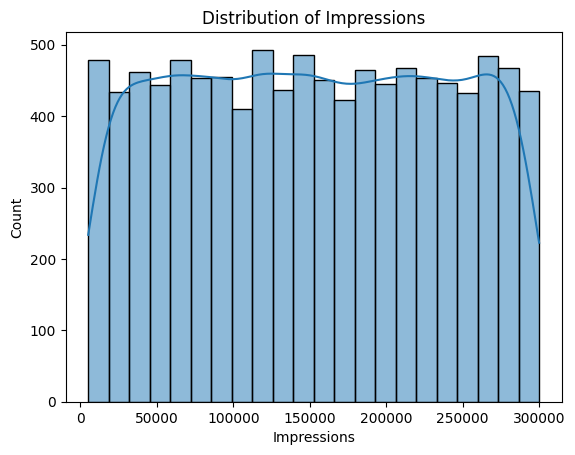

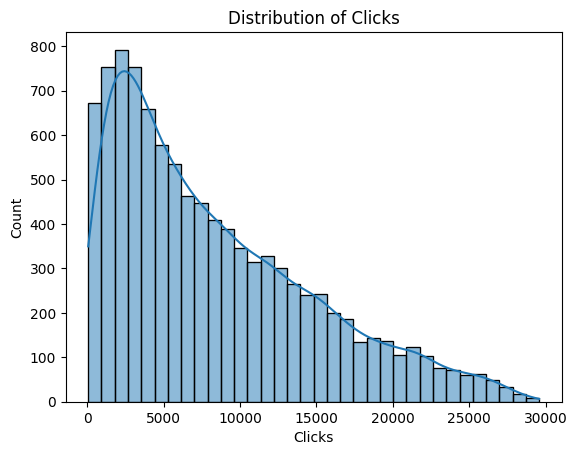

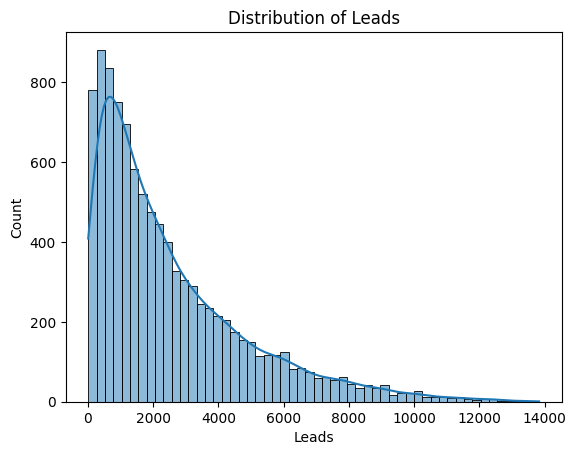

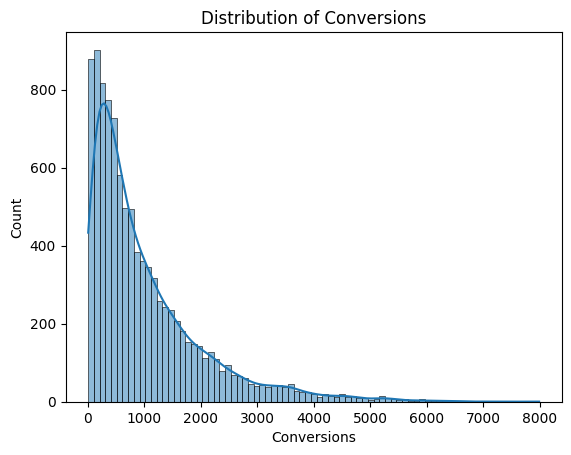

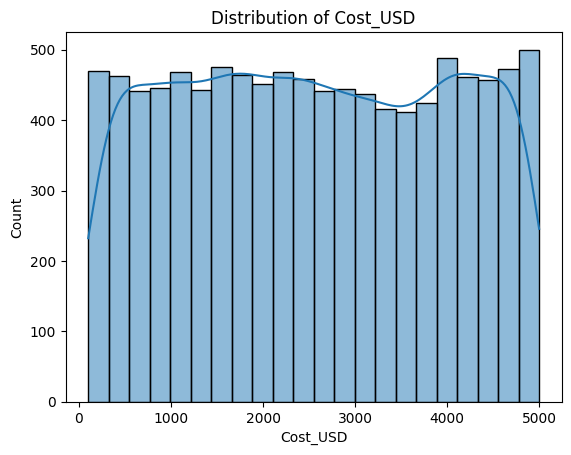

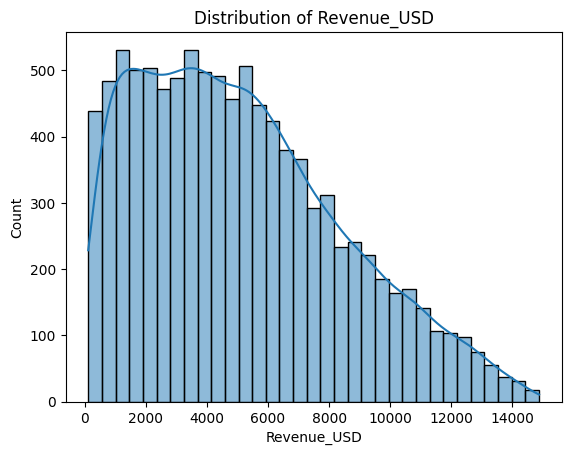

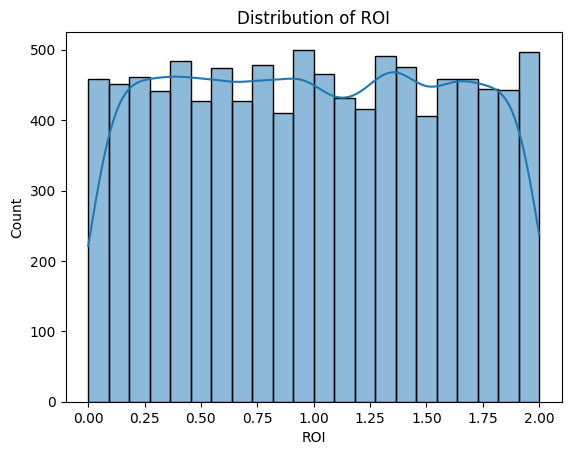

In [214]:
num = df.select_dtypes(include=[int,float]).columns.tolist()
for i in num:
    sns.histplot(df[i],kde=True)
    plt.title(f"Distribution of {i}")
    plt.show()


<Axes: >

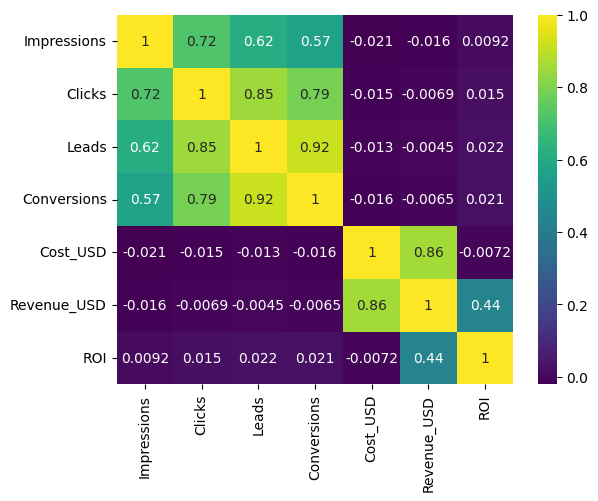

In [215]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="viridis")

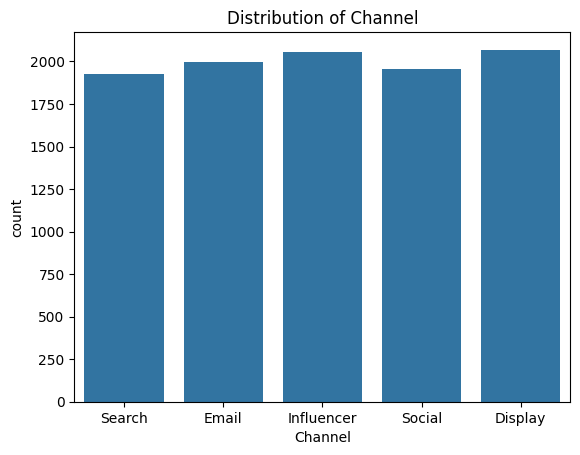

In [216]:
sns.countplot(x="Channel", data=df)
plt.title("Distribution of Channel")
plt.show()

In [217]:
df = pd.get_dummies(df,columns=["Channel"], drop_first=True)

In [218]:
df["Revenue_Category"] = pd.qcut(df["Revenue_USD"],q=3,labels=["Low", "Medium", "High"],duplicates='drop')

In [219]:
from sklearn.preprocessing import LabelEncoder

Le = LabelEncoder()

In [220]:
df["Revenue_Category"] = Le.fit_transform(
    df["Revenue_Category"]
)

In [221]:
cols = df.select_dtypes(include='bool').columns
df[cols] = df[cols].astype(int)


In [222]:
df.head()

,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI,Channel_Email,Channel_Influencer,Channel_Search,Channel_Social,Revenue_Category
0,293520,23335,11643,5389,1052.39,2236.02,1.12,0,0,1,0,1
1,200340,15841,6601,2498,3964.90,11740.15,1.96,0,0,1,0,0
2,239365,16478,8043,3397,1000.39,1902.24,0.90,1,0,0,0,1
3,156382,2672,1014,342,1252.63,2209.74,0.76,0,0,1,0,1
4,285472,4155,1521,565,4935.48,14111.31,1.86,0,1,0,0,0


In [223]:
from scipy.stats import pearsonr

In [224]:


Selected_Features = [
    "Impressions",
    "Clicks",
    "Leads",
    "Conversions",
    "Cost_USD",
    "ROI",
    "Channel_Email",
    "Channel_Influencer",
    "Channel_Search",
    "Channel_Social"
]

correlation = {
    Feature: pearsonr(df[Feature], df["Revenue_USD"])[0]
    for Feature in Selected_Features
}

correlation_df = pd.DataFrame(list(correlation.items()),columns=["Feature","Correlation_with_Revenue_Category"])

correlation_df = correlation_df.sort_values(by="Correlation_with_Revenue_Category",ascending=False)

print(correlation_df)

              Feature  Correlation_with_Revenue_Category
4            Cost_USD                           0.859691
5                 ROI                           0.438801
8      Channel_Search                           0.006147
7  Channel_Influencer                           0.005015
6       Channel_Email                          -0.004109
2               Leads                          -0.004509
3         Conversions                          -0.006510
1              Clicks                          -0.006921
0         Impressions                          -0.015958
9      Channel_Social                          -0.019099


In [225]:
X = df.drop("Revenue_USD", axis=1)
y = df["Revenue_USD"]

In [226]:
from sklearn.model_selection import train_test_split

In [227]:
x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [228]:
from sklearn.preprocessing import StandardScaler

In [229]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [230]:
from sklearn.linear_model import LinearRegression

In [231]:
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [236]:
y_pred = model.predict(x_test)
y_pred

array([ 2518.69725971,  8333.8311367 , 11867.28017418, ...,
        7069.82681179,  9275.48692381, 10317.66798177], shape=(2000,))

In [239]:
comparison_df = pd.DataFrame({
    "Actual_Revenue": y_test,
    "Predicted_Revenue": y_pred
})

comparison_df.head(10)

,Actual_Revenue,Predicted_Revenue
6252,2266.61,2518.697260
4684,8106.46,8333.831137
1731,13866.02,11867.280174
4742,7581.66,8528.089620
4521,7374.73,7683.650648
6340,4249.79,5121.456859
576,10720.10,10162.274374
5202,7837.83,7896.749050
6363,585.53,-689.270833
439,2791.23,2575.948387


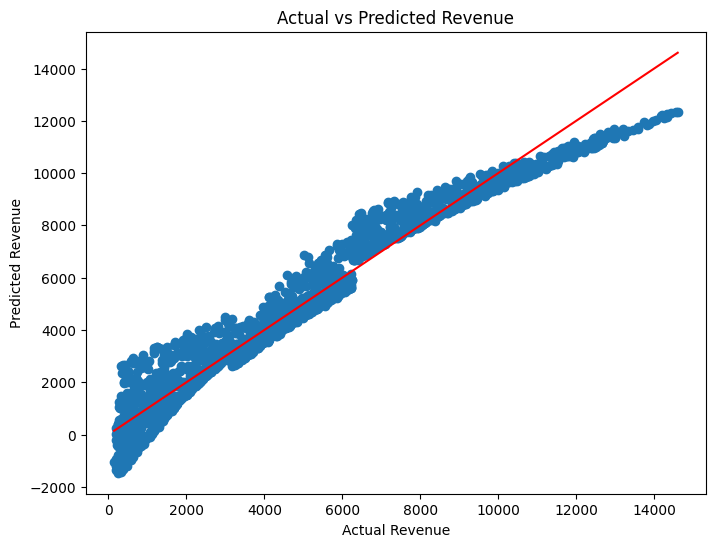

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred)

plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color='red')

plt.xlabel("Actual Revenue")

plt.ylabel("Predicted Revenue")

plt.title("Actual vs Predicted Revenue")


plt.show()

In [233]:
from sklearn.metrics import r2_score

print("R2 Score :", r2_score(y_test, y_pred))



R2 Score : 0.9500939243218113


In [235]:
adjusted_r2 = 1 - (1 - r2_score(y_test, y_pred)) * (len(y_test) - 1) / (len(y_test) - X.shape[1] - 1)
print("Adjusted R2 Score :", adjusted_r2)

Adjusted R2 Score : 0.9498177840640346
